# Active inverse optimization: uniform queries + sequential incenter

This notebook is a permanent, fully executed record of the first active inverse-optimization baseline. The environment is deliberately simple: dimension 2, true parameter $\theta^\star=(0.8,-0.6)$, independent binary decisions, an exact minimizing expert, 24 dense unit-norm query candidates, no observation noise, and no parameter noise.

The maximum horizon is 12 rounds. The algorithm chooses a permitted query $S_t$ uniformly at random, observes only $Y_t$, adds the resulting consistency hyperplanes, and uses the normalized cone incenter as $\hat\theta_t$. After every update, the external benchmark rule checks the estimate on 200 hidden uniform test queries and stops at the first zero-regret time; otherwise it continues to round 12. The primary measurements are angular error and normalized clean regret. The hidden test queries and $\theta^\star$ are used only by the evaluator and stopping rule, never by the algorithm.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from invoptlab.active import (
    ActiveBenchmarkRunner,
    ActiveEvaluationConfig,
    ActiveScenarioConfig,
    DecisionSpaceConfig,
    ExpertConfig,
    ObservationNoiseConfig,
    ParameterNoiseConfig,
    QuerySpaceConfig,
    RegretStoppingConfig,
    UniformRandomIncenterAlgorithm,
    evaluate_active_run,
)

DIMENSION = 2
HORIZON = 12
TRUE_THETA = np.array([0.8, -0.6])
TRAINING_SEED = 21
CANDIDATE_COUNT = 24
TEST_QUERY_COUNT = 200
EVALUATION_SEED = 104

settings = pd.DataFrame({
    'setting': ['dimension', 'horizon', 'true theta', 'decision space', 'query space',
                'candidate count', 'expert', 'observation noise', 'parameter noise',
                'training seed', 'hidden test queries', 'evaluation seed'],
    'value': [DIMENSION, HORIZON, str(TRUE_THETA), 'independent binary', 'dense unit vectors',
              CANDIDATE_COUNT, 'exact MIN', 'none', 'none', TRAINING_SEED,
              TEST_QUERY_COUNT, EVALUATION_SEED],
})
display(settings)

,setting,value
0,dimension,2
1,horizon,12
2,true theta,[ 0.8 -0.6]
3,decision space,independent binary
4,query space,dense unit vectors
5,candidate count,24
6,expert,exact MIN
7,observation noise,none
8,parameter noise,none
9,training seed,21


In [2]:
scenario = ActiveScenarioConfig(
    name='clean-2d-uniform-random-sequential-incenter',
    dimension=DIMENSION,
    horizon=HORIZON,
    seed=TRAINING_SEED,
    true_theta=TRUE_THETA,
    expert=ExpertConfig(kind='min'),
    decision_space=DecisionSpaceConfig(kind='independent_binary'),
    query_space=QuerySpaceConfig(
        kind='dense',
        candidate_count=CANDIDATE_COUNT,
        allow_repeated_queries=True,
    ),
    observation_noise=ObservationNoiseConfig(kind='clean'),
    parameter_noise=ParameterNoiseConfig(kind='none'),
)
algorithm = UniformRandomIncenterAlgorithm()
stopping = RegretStoppingConfig(
    test_query_count=TEST_QUERY_COUNT,
    seed=EVALUATION_SEED,
)
run = ActiveBenchmarkRunner(stopping_config=stopping).run(scenario, algorithm)
print(f'Executed {len(run.records)} of at most {HORIZON} interactions without error.')
print(f"Stopping criterion met: {run.metadata['stopping_criterion_met']}")
print(f"Stopping time: {run.metadata['stopping_time']}")

Executed 1 of at most 12 interactions without error.
Stopping criterion met: True
Stopping time: 1


In [3]:
evaluation = evaluate_active_run(
    run,
    ActiveEvaluationConfig(
        test_query_count=TEST_QUERY_COUNT,
        seed=EVALUATION_SEED,
        evaluate_trajectory=True,
    ),
)
final_theta = run.parameter_history[-1]
final_diagnostics = run.records[-1].update_diagnostics
summary = pd.DataFrame({
    'measurement': [
        'true theta', 'final theta hat', 'angular error (degrees)',
        'normalized test regret', 'zero-regret test-query rate',
        'final incenter radius', 'final hyperplane count', 'stopping time',
        'zero-regret stopping achieved', 'runtime (seconds)'
    ],
    'value': [
        np.array2string(run.true_theta, precision=6),
        np.array2string(final_theta, precision=6),
        evaluation.final_angular_error_degrees,
        evaluation.final_normalized_regret,
        evaluation.final_zero_regret_rate,
        final_diagnostics['incenter_radius'],
        final_diagnostics['constraint_count'],
        run.metadata['stopping_time'],
        run.metadata['stopping_criterion_met'],
        run.runtime_seconds,
    ],
})
display(summary)

,measurement,value
0,true theta,[ 0.8 -0.6]
1,final theta hat,[ 0.707107 -0.707107]
2,angular error (degrees),8.130102
3,normalized test regret,0.0
4,zero-regret test-query rate,1.0
5,final incenter radius,0.707107
6,final hyperplane count,2
7,stopping time,1
8,zero-regret stopping achieved,True
9,runtime (seconds),1.297717


In [4]:
trajectory = pd.DataFrame({
    't': np.arange(1, len(run.records) + 1),
    'theta_hat_1': run.parameter_history[:, 0],
    'theta_hat_2': run.parameter_history[:, 1],
    'angular_error_deg': evaluation.angular_error_history_degrees,
    'normalized_test_regret': evaluation.normalized_regret_history,
    'zero_regret_rate': evaluation.zero_regret_rate_history,
    'incenter_radius': [record.update_diagnostics['incenter_radius'] for record in run.records],
    'hyperplanes': [record.update_diagnostics['constraint_count'] for record in run.records],
    'query_index': [record.action_diagnostics['candidate_index'] for record in run.records],
})
display(trajectory.round(6))

,t,theta_hat_1,theta_hat_2,angular_error_deg,normalized_test_regret,zero_regret_rate,incenter_radius,hyperplanes,query_index
0,1,0.707107,-0.707107,8.130102,0.0,1.0,0.707107,2,9


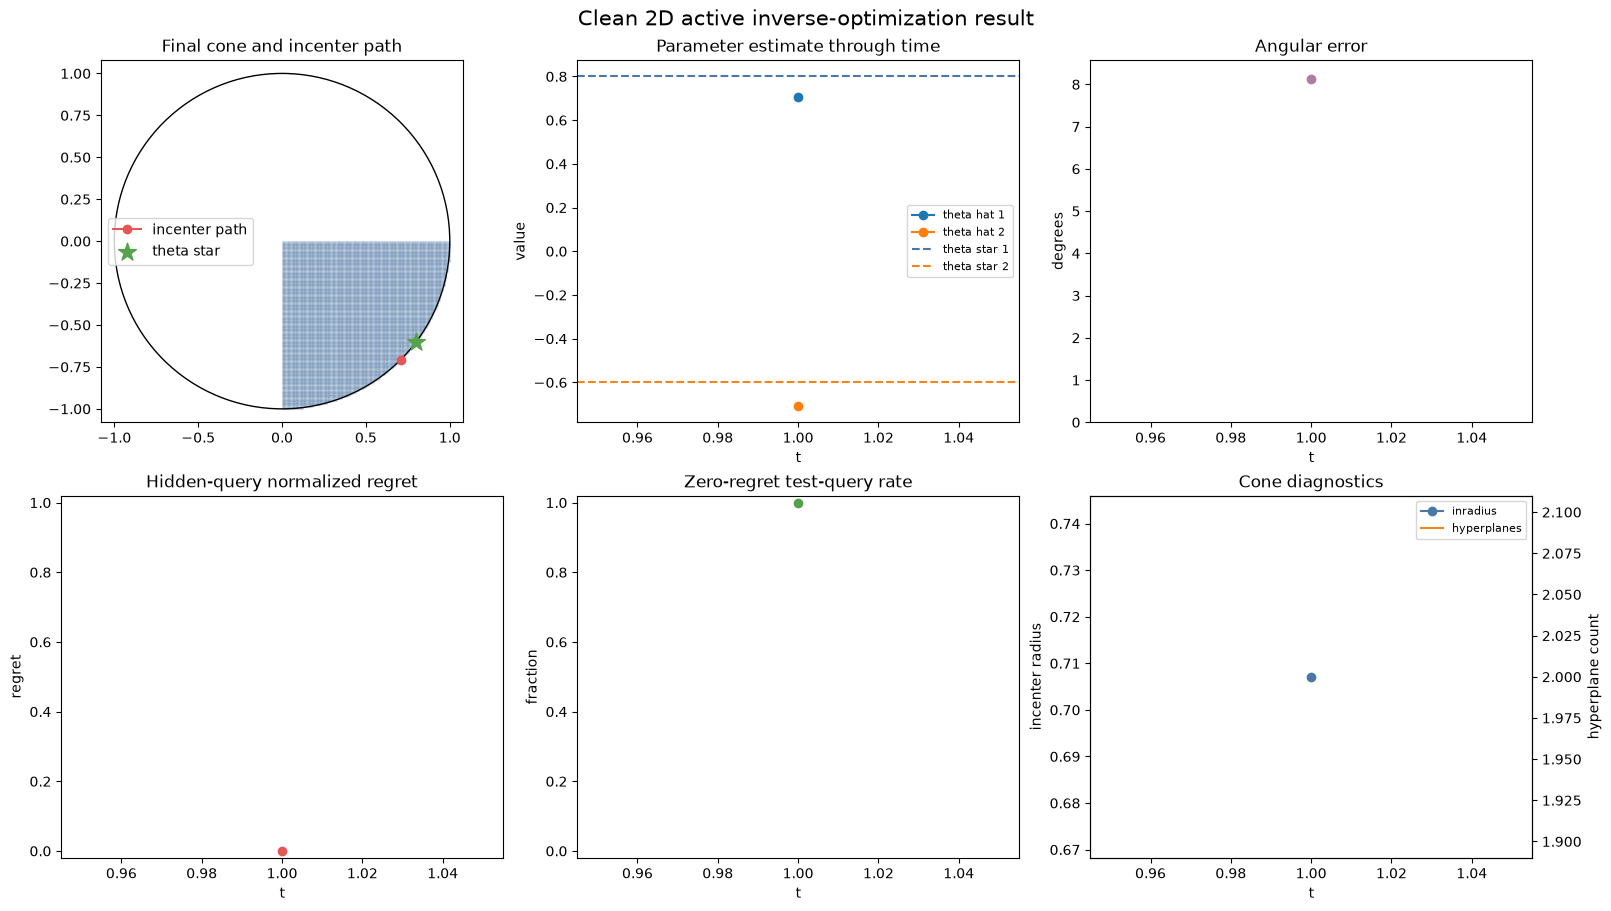

In [5]:
steps = trajectory['t'].to_numpy()
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)

# Final consistency cone intersected with the unit disk.
grid_axis = np.linspace(-1.05, 1.05, 220)
g1, g2 = np.meshgrid(grid_axis, grid_axis)
points = np.column_stack([g1.ravel(), g2.ravel()])
inside_ball = np.linalg.norm(points, axis=1) <= 1.0
inside_cone = np.all(algorithm.constraints_ @ points.T <= 1e-9, axis=0)
feasible = points[inside_ball & inside_cone]
axes[0, 0].scatter(feasible[:, 0], feasible[:, 1], s=2, alpha=0.16, color='#4C78A8')
circle = plt.Circle((0, 0), 1, fill=False, color='black', linewidth=1)
axes[0, 0].add_patch(circle)
path = run.parameter_history
axes[0, 0].plot(path[:, 0], path[:, 1], 'o-', color='#E45756', label='incenter path')
axes[0, 0].scatter(*run.true_theta, marker='*', s=180, color='#54A24B', label='theta star')
axes[0, 0].set(xlim=(-1.08, 1.08), ylim=(-1.08, 1.08), aspect='equal', title='Final cone and incenter path')
axes[0, 0].legend()

axes[0, 1].plot(steps, path[:, 0], 'o-', label='theta hat 1')
axes[0, 1].plot(steps, path[:, 1], 'o-', label='theta hat 2')
axes[0, 1].axhline(run.true_theta[0], linestyle='--', color='#4C78A8', label='theta star 1')
axes[0, 1].axhline(run.true_theta[1], linestyle='--', color='#F58518', label='theta star 2')
axes[0, 1].set(title='Parameter estimate through time', xlabel='t', ylabel='value')
axes[0, 1].legend(fontsize=8)

axes[0, 2].plot(steps, trajectory['angular_error_deg'], 'o-', color='#B279A2')
axes[0, 2].set(title='Angular error', xlabel='t', ylabel='degrees', ylim=(0, None))

axes[1, 0].plot(steps, trajectory['normalized_test_regret'], 'o-', color='#E45756')
axes[1, 0].set(title='Hidden-query normalized regret', xlabel='t', ylabel='regret', ylim=(-0.02, 1.02))

axes[1, 1].plot(steps, trajectory['zero_regret_rate'], 'o-', color='#54A24B')
axes[1, 1].set(title='Zero-regret test-query rate', xlabel='t', ylabel='fraction', ylim=(-0.02, 1.02))

axes[1, 2].plot(steps, trajectory['incenter_radius'], 'o-', color='#4C78A8', label='inradius')
axes[1, 2].set(title='Cone diagnostics', xlabel='t', ylabel='incenter radius')
count_axis = axes[1, 2].twinx()
count_axis.step(steps, trajectory['hyperplanes'], where='mid', color='#F58518', label='hyperplanes')
count_axis.set_ylabel('hyperplane count')
lines = axes[1, 2].get_lines() + count_axis.get_lines()
axes[1, 2].legend(lines, [line.get_label() for line in lines], fontsize=8)

fig.suptitle('Clean 2D active inverse-optimization result', fontsize=15)
plt.show()

In [6]:
output_path = Path('../outputs/active/clean-2d-uniform-incenter.json')
run.save_json(output_path)
print(f'Raw trajectory saved to: {output_path.resolve()}')
print('The tables and plots above are also stored permanently inside this executed notebook.')

Raw trajectory saved to: C:\Users\payam\Desktop\Inverse Optimization\outputs\active\clean-2d-uniform-incenter.json
The tables and plots above are also stored permanently inside this executed notebook.
